In [19]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.activations import sigmoid
import matplotlib.pyplot as plt
import warnings
warnings.simplefilter(action='ignore', category=Warning)

In [2]:
X = np.load("data/X.npy")
y = np.load("data/y.npy")
X = X[:1000]
y = y[:1000]

In [3]:
print("First element of X: ", X[0])
print("Shape of X: ", X.shape)

First element of X:  [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.

In [4]:
print("First 5 element of y: ", y[:5])
print("Shape of y: ", y.shape)

First 5 element of y:  [[0]
 [0]
 [0]
 [0]
 [0]]
Shape of y:  (1000, 1)


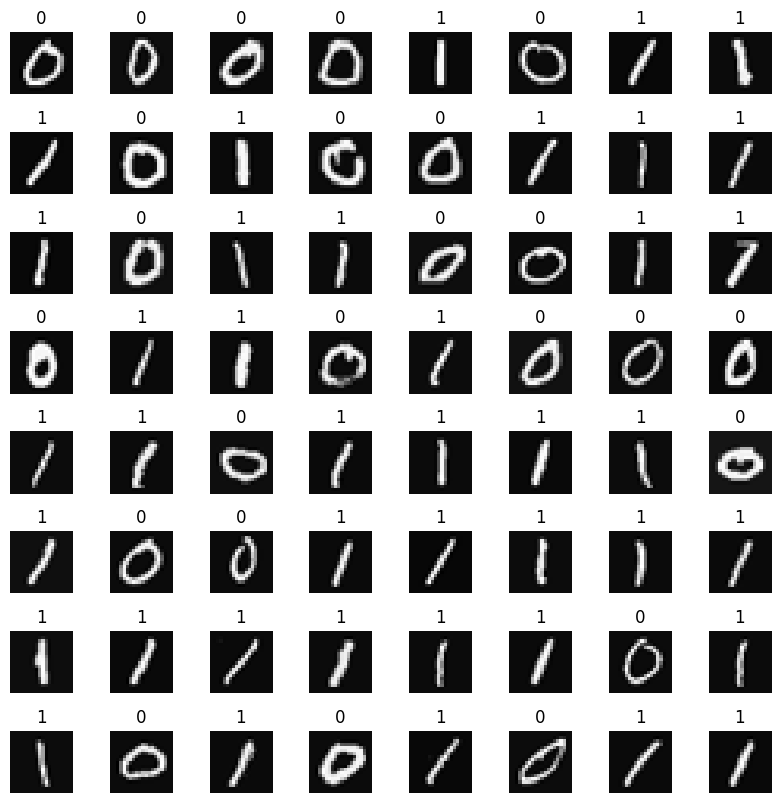

In [5]:
m,n = X.shape

fig, axes = plt.subplots(8,8, figsize=(8,8))
fig.tight_layout(pad=0.1)

for i, ax in enumerate(axes.flat):
    random_index = np.random.randint(m)
    X_random_reshaped = X[random_index].reshape((20,20)).T
    ax.imshow(X_random_reshaped, cmap='gray')
    ax.set_title(y[random_index, 0])
    ax.set_axis_off()

In [6]:
model = Sequential(
    [
        tf.keras.Input(shape=(400,)),
        Dense(25, activation='sigmoid'),
        Dense(15, activation='sigmoid'),
        Dense(1, activation='sigmoid')
    ], name="my_model"
)

In [7]:
model.summary()

Model: "my_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 25)                10025     
                                                                 
 dense_1 (Dense)             (None, 15)                390       
                                                                 
 dense_2 (Dense)             (None, 1)                 16        
                                                                 
Total params: 10,431
Trainable params: 10,431
Non-trainable params: 0
_________________________________________________________________


L1_num_params = 400 * 25 + 25  # W1 parameters  + b1 parameters

L2_num_params = 25 * 15 + 15   # W2 parameters  + b2 parameters

L3_num_params = 15 * 1 + 1     # W3 parameters  + b3 parameters

In [8]:
[layer1, layer2, layer3] = model.layers

In [9]:
w1, b1 = layer1.get_weights()
w2, b2 = layer2.get_weights()
w3, b3 = layer3.get_weights()
print(f'W1 shape: {w1.shape}, b1 shape: {b1.shape}')
print(f'W2 shape: {w2.shape}, b2 shape: {b2.shape}')
print(f'W3 shape: {w3.shape}, b3 shape: {b3.shape}')

W1 shape: (400, 25), b1 shape: (25,)
W2 shape: (25, 15), b2 shape: (15,)
W3 shape: (15, 1), b3 shape: (1,)


In [10]:
model.layers[2].weights

[<tf.Variable 'dense_2/kernel:0' shape=(15, 1) dtype=float32, numpy=
 array([[-0.28431746],
        [ 0.33311462],
        [ 0.08625752],
        [ 0.18916619],
        [-0.33695623],
        [-0.433178  ],
        [ 0.59067994],
        [-0.56684893],
        [ 0.13243526],
        [-0.32564554],
        [-0.5172404 ],
        [ 0.03600293],
        [-0.12449327],
        [-0.33965972],
        [ 0.26680493]], dtype=float32)>,
 <tf.Variable 'dense_2/bias:0' shape=(1,) dtype=float32, numpy=array([0.], dtype=float32)>]

In [11]:
model.compile(
    loss=tf.keras.losses.BinaryCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(0.001)
)

model.fit(X, y, epochs=20)

Epoch 1/20
32/32 [==============================] - 1s 2ms/step - loss: 0.6416
Epoch 2/20
32/32 [==============================] - 0s 2ms/step - loss: 0.4892
Epoch 3/20
32/32 [==============================] - 0s 2ms/step - loss: 0.3508
Epoch 4/20
32/32 [==============================] - 0s 2ms/step - loss: 0.2465
Epoch 5/20
32/32 [==============================] - 0s 2ms/step - loss: 0.1795
Epoch 6/20
32/32 [==============================] - 0s 2ms/step - loss: 0.1369
Epoch 7/20
32/32 [==============================] - 0s 2ms/step - loss: 0.1086
Epoch 8/20
32/32 [==============================] - 0s 2ms/step - loss: 0.0889
Epoch 9/20
32/32 [==============================] - 0s 2ms/step - loss: 0.0745
Epoch 10/20
32/32 [==============================] - 0s 2ms/step - loss: 0.0635
Epoch 11/20
32/32 [==============================] - 0s 2ms/step - loss: 0.0550
Epoch 12/20
32/32 [==============================] - 0s 2ms/step - loss: 0.0483
Epoch 13/20
32/32 [==============================

In [12]:
prediction = model.predict(X[0].reshape(1,400)) # a zero
print("Predicting a zero: ", prediction)
prediction = model.predict(X[500].reshape(1,400)) # a one
print("Predicting a one: ", prediction)

1/1 [==============================] - 0s 57ms/step
Predicting a zero:  [[0.01457998]]
1/1 [==============================] - 0s 16ms/step
Predicting a one:  [[0.97806716]]


In [13]:
if prediction >= 0.5:
    yhat = 1
else:
    yhat = 0
print("Prediction after threshold: ", yhat)

Prediction after threshold:  1


1/1 [==============================] - 0s 15ms/step


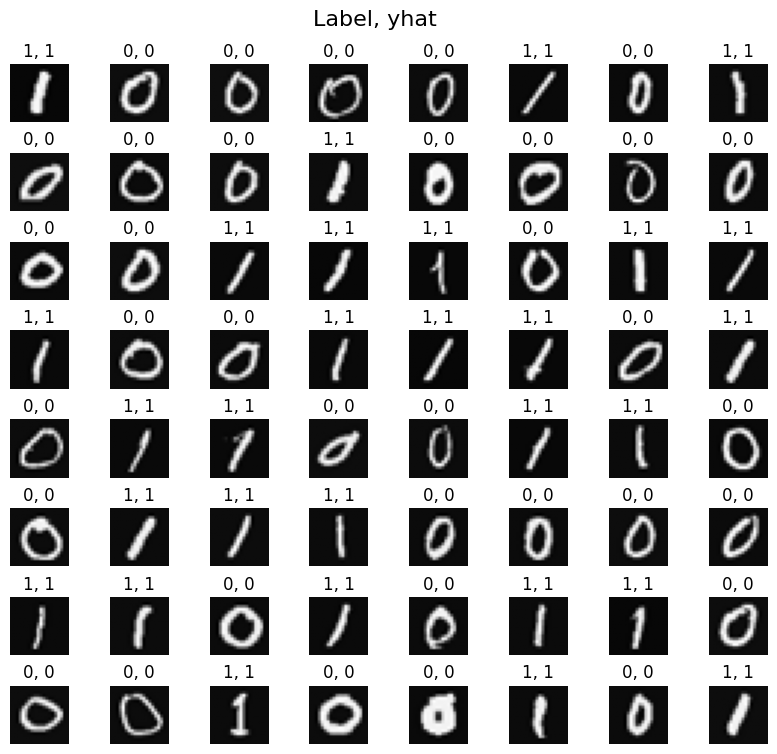

In [17]:
m,n = X.shape

fig, axes = plt.subplots(8,8, figsize=(8,8))
fig.tight_layout(pad=0.1, rect=[0, 0.03, 1, 0.92])

for i,ax in enumerate(axes.flat):
    random_index = np.random.randint(m)
    X_random_reshaped = X[random_index].reshape((20,20)).T
    ax.imshow(X_random_reshaped, cmap='gray')

    prediction = model.predict(X[random_index].reshape(1,400))
    if prediction >= 0.5:
        yhat = 1
    else:
        yhat = 0

    ax.set_title(f'{y[random_index,0]}, {yhat}')
    ax.set_axis_off()
fig.suptitle("Label, yhat", fontsize=16)
plt.show()

## Implementing Neural Netwoek in Numpy

In [18]:
def my_dense(a_in, W, b, g):
    """
    Computes dense layer
    
    Args:
      a_in (ndarray (n, )) : Data, 1 example
      W    (ndarray (n,j)) : Weight matrix, n features per unit, j units
      b    (ndarray (j, )) : bias vector, j units  
      g    activation function (e.g. sigmoid, relu..)
    
    Returns:
      a_out (ndarray (j,))  : j units
    """
    units = W.shape[1]
    a_out = np.zeros(units)

    for unit in range(units):
        z = np.dot(W[:, unit], a_in) + b[unit]
        a_out[unit] = g(z)

    return a_out

In [20]:
x_tst = 0.1*np.arange(1,3,1).reshape(2,)  # (1 examples, 2 features)
W_tst = 0.1*np.arange(1,7,1).reshape(2,3) # (2 input features, 3 output features)
b_tst = 0.1*np.arange(1,4,1).reshape(3,)  # (3 features)
A_tst = my_dense(x_tst, W_tst, b_tst, sigmoid)
print(A_tst)

[0.54735762 0.57932425 0.61063923]


In [21]:
def my_sequential(x, W1, b1, W2, b2, W3, b3):
    a1 = my_dense(x,  W1, b1, sigmoid)
    a2 = my_dense(a1, W2, b2, sigmoid)
    a3 = my_dense(a2, W3, b3, sigmoid)
    return(a3)

In [22]:
W1_tmp,b1_tmp = layer1.get_weights()
W2_tmp,b2_tmp = layer2.get_weights()
W3_tmp,b3_tmp = layer3.get_weights()

In [23]:
prediction = my_sequential(X[0], W1_tmp, b1_tmp, W2_tmp, b2_tmp, W3_tmp, b3_tmp)
if prediction >= 0.5:
    yhat = 1
else: 
    yhat = 0
print("yhat = ", yhat, " label = ", y[0,0])

prediction = my_sequential(X[500], W1_tmp, b1_tmp, W2_tmp, b2_tmp, W3_tmp, b3_tmp)
if prediction >= 0.5:
    yhat = 1
else: 
    yhat = 0
print("yhat = ", yhat, " label = ", y[500,0])

yhat =  0  label =  0
yhat =  1  label =  1


1/1 [==============================] - 0s 15ms/step


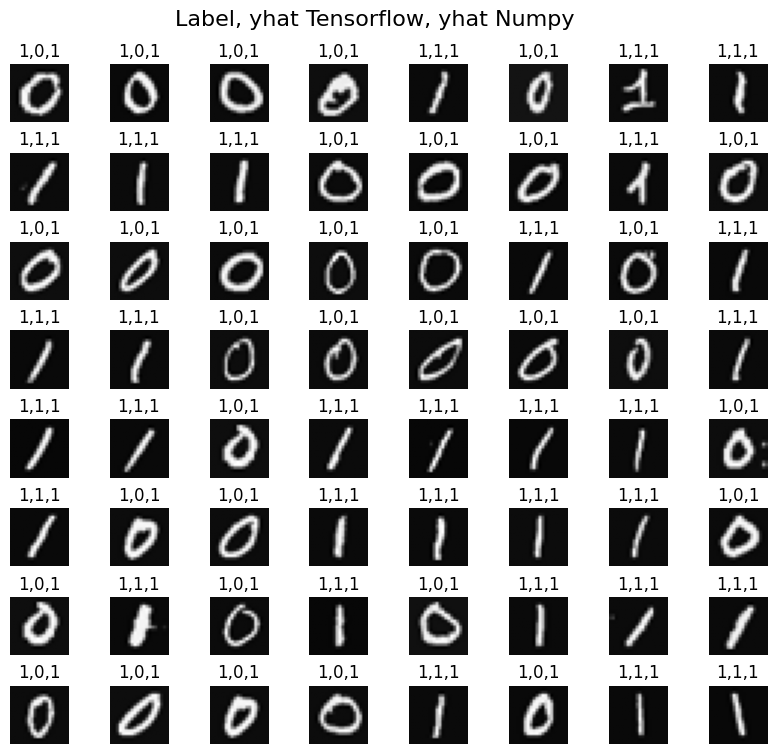

In [25]:
m,n = X.shape

fig, axes = plt.subplots(8,8, figsize=(8,8))
fig.tight_layout(pad=0.1, rect=[0, 0.03, 1, 0.92])

for i,ax in enumerate(axes.flat):
    random_indes = np.random.randint(m)
    X_random_reshaped = X[random_indes].reshape((20,20)).T
    ax.imshow(X_random_reshaped, cmap='gray')
    
    my_prediction = my_sequential(X[random_index], W1_tmp, b1_tmp, W2_tmp, b2_tmp, W3_tmp, b3_tmp)
    my_yhat = int(my_prediction >= 0.5)

    tf_prediction = model.predict(X[random_indes].reshape(1,400))
    tf_yhat = int(tf_prediction >= 0.5)

    ax.set_title(f"{y[random_index,0]},{tf_yhat},{my_yhat}")
    ax.set_axis_off() 
fig.suptitle("Label, yhat Tensorflow, yhat Numpy", fontsize=16)
plt.show()

## Vectorized NumPy Model Implementation

In [26]:
def my_dense_v(A_in, W, b, g):
    """
    Computes dense layer
    
    Args:
      A_in (ndarray (m,n)) : Data, m examples, n features each
      W    (ndarray (n,j)) : Weight matrix, n features per unit, j units
      b    (ndarray (1,j)) : bias vector, j units  
      g    activation function (e.g. sigmoid, relu..)
    
    Returns
      A_out (tf.Tensor or ndarray (m,j)) : m examples, j units
    """
    z = np.matmul(A_in, W) + b
    A_out = g(z)

    return A_out

In [27]:
X_tst = 0.1*np.arange(1,9,1).reshape(4,2) # (4 examples, 2 features)
W_tst = 0.1*np.arange(1,7,1).reshape(2,3) # (2 input features, 3 output features)
b_tst = 0.1*np.arange(1,4,1).reshape(1,3) # (1,3 features)
A_tst = my_dense_v(X_tst, W_tst, b_tst, sigmoid)
print(A_tst)

tf.Tensor(
[[0.54735762 0.57932425 0.61063923]
 [0.57199613 0.61301418 0.65248946]
 [0.5962827  0.64565631 0.6921095 ]
 [0.62010643 0.67699586 0.72908792]], shape=(4, 3), dtype=float64)


In [28]:
def my_sequential_v(X, W1, b1, W2, b2, W3, b3):
    A1 = my_dense_v(X,  W1, b1, sigmoid)
    A2 = my_dense_v(A1, W2, b2, sigmoid)
    A3 = my_dense_v(A2, W3, b3, sigmoid)
    return(A3)

In [29]:
W1_tmp,b1_tmp = layer1.get_weights()
W2_tmp,b2_tmp = layer2.get_weights()
W3_tmp,b3_tmp = layer3.get_weights()

In [30]:
Prediction = my_sequential_v(X, W1_tmp, b1_tmp, W2_tmp, b2_tmp, W3_tmp, b3_tmp )
Prediction.shape

TensorShape([1000, 1])

In [32]:
Yhat = (Prediction >= 0.5).numpy().astype(int)
# Yhat = tf.cast(Prediction >= 0.5, tf.int32)
print("predict a zero: ",Yhat[0], "predict a one: ", Yhat[500])

predict a zero:  [0] predict a one:  [1]


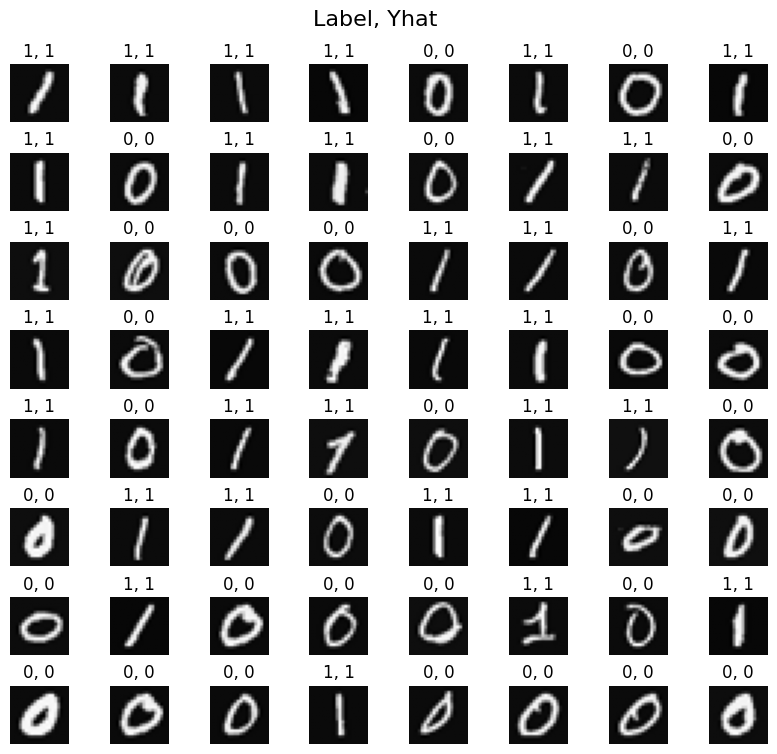

In [33]:
m, n = X.shape

fig, axes = plt.subplots(8, 8, figsize=(8, 8))
fig.tight_layout(pad=0.1, rect=[0, 0.03, 1, 0.92]) 

for i, ax in enumerate(axes.flat):
    random_index = np.random.randint(m)
    X_random_reshaped = X[random_index].reshape((20, 20)).T
    ax.imshow(X_random_reshaped, cmap='gray')
   
    ax.set_title(f"{y[random_index,0]}, {Yhat[random_index, 0]}")
    ax.set_axis_off() 
fig.suptitle("Label, Yhat", fontsize=16)
plt.show()

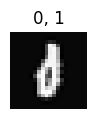

In [34]:
fig = plt.figure(figsize=(1, 1))
errors = np.where(y != Yhat)
random_index = errors[0][0]
X_random_reshaped = X[random_index].reshape((20, 20)).T
plt.imshow(X_random_reshaped, cmap='gray')
plt.title(f"{y[random_index,0]}, {Yhat[random_index, 0]}")
plt.axis('off')
plt.show()